# CSCI 270 - Computational Humanities
# Lab 3 - Document Clustering

In [1]:
from scipy.cluster import hierarchy
import numpy as np
import matplotlib.pyplot as plt
import random
import math
import os
import re
from typing import *

# Setup

Add the CSCI 270 Books and Poems data sets to this notebook's data.

As we develop functions to enable us to perform data clustering, we will use the dictionary given below. Later on, once our functions are working, we will load our documents from files into a dictionary with the same setup, where the keys are filenames (serving as document titles) and the values are the documents themselves.

In [2]:
filename2document = {"A": "wet snow falls in winter snow falls", 
                     "B": "cold and wet in winter", 
                     "C": "cold wet snow packs best best", 
                     "D": "cold snow is cold and wet"}

The `assess()` function returns `True` if its parameters match, and `False` otherwise. It also prints out the first value. We will use this function to test each of the functions we write.

In [3]:
def assess(value, expected):
    print(value)
    return value == expected

## Lab 2 Functions

In the code block below, copy over the following functions you wrote in Lab 2:
* `file_dictionary()`
* `all_tokens_from()`
* `count()`
* `count_all()`

In [4]:
def file_dictionary(file_path: str) -> Dict[str,str]:
    #write a loop that goes over every file in the directory and stores 
    #them in the dictionary using os.walk and os.path.join
    content = {}
    for dirname, _, filenames in os.walk(file_path):
        for filename in filenames:
            poem_open = open(os.path.join(dirname, filename)).read()
            content[filename] = poem_open
    return content

def all_tokens_from(text: str) -> List[str]:
    tokens = []
    for token in re.findall(r'\b\w+\b', text.lower()):
        tokens.append(token)
    return tokens

def count(histogram: Dict[Hashable,int], item: Hashable):
    # Look up item in dictionary: if not present then it= 1, if presen then it +=1
    if item in histogram:
        histogram[item] += 1
    else:
        histogram[item] = 1
    
def count_all(items: Iterable[Hashable]) -> Dict[Hashable,int]:
    # Create a dictionary, and call count() for each item
    tryDict = {}

    for item in items:
        if item in tryDict:
            tryDict[item] += 1
        else:
            tryDict[item] = 1

    return tryDict

# Part 1 - Finding tf-idf matrix

Write a function to find the **term frequencies** for all documents. It should return a dictionary, where the key is the name of the document, and the value is a dictionary of term frequency counts, that is, a histogram counting the number of occurrences of each token in that document.

Note that throughout this lab, **term** and **token** are synonyms.

In [5]:

def all_letters_from(text: str) -> str:
    return re.sub(r'[^a-zA-Z\s]', '', text)

def term_freqs(documents: Dict[str, str]) -> Dict[str, Dict[str, int]]:
    terms = {}

    for doc_name, doc_content in documents.items():
        letters_doc = all_letters_from(doc_content.lower()) 
        tokens = letters_doc.split()
        term_freq_count = {}
        for token in tokens:
            term_freq_count[token] = term_freq_count.get(token, 0) + 1
        terms[doc_name] = term_freq_count

    return terms


In [6]:
tf = term_freqs(filename2document)
assess(tf, {'A': {'wet': 1, 'snow': 2, 'falls': 2, 'in': 1, 'winter': 1},
            'B': {'cold': 1, 'and': 1, 'wet': 1, 'in': 1, 'winter': 1},
            'C': {'cold': 1, 'wet': 1, 'snow': 1, 'packs': 1, 'best': 2},
            'D': {'cold': 2, 'snow': 1, 'is': 1, 'and': 1, 'wet': 1}})

{'A': {'wet': 1, 'snow': 2, 'falls': 2, 'in': 1, 'winter': 1}, 'B': {'cold': 1, 'and': 1, 'wet': 1, 'in': 1, 'winter': 1}, 'C': {'cold': 1, 'wet': 1, 'snow': 1, 'packs': 1, 'best': 2}, 'D': {'cold': 2, 'snow': 1, 'is': 1, 'and': 1, 'wet': 1}}


True

Write a function to return a **sorted** list of all terms in the corpus. By using an object of the `set()` class as an intermediate step, we facilitate fast lookup when checking for uniqueness.

In [7]:
def all_terms(documents: Dict[str,str]) -> List[str]:
    #open docs like did above
    # make a set
    #split the tokens in each doc
    #update set
   
    tryset = set()
    for document in documents.values():
        words = document.split()
        tryset.update(words)
    sorted_terms_list = sorted(list(tryset))
    return sorted_terms_list






In [8]:
terms = all_terms(filename2document) 
assess(terms, ['and', 'best', 'cold', 'falls', 'in', 'is', 'packs', 'snow', 'wet', 'winter'])

['and', 'best', 'cold', 'falls', 'in', 'is', 'packs', 'snow', 'wet', 'winter']


True

In addition to having a master list of all terms in all the documents, it is useful to represent each document by the terms it specifically contains. Write a function that returns a list of sets of terms from each document. 

In [9]:
def document_term_sets(documents: Dict[str,str]) -> List[Set[str]]:
    # take a set and then split docs into words
    #then add to the list 
    doc_set = []
    
    for document in documents.values():
        terms = set(document.split())

        doc_set.append(terms)
        
    return doc_set

novel_path = "/kaggle/input/novels-hendrix-csci-270-spring-2024/AliceInWonderLand_Carroll_Hamilton.txt"
poem_path = "/kaggle/input/poems-hendrix-csci-270-spring-2024/Frost_RoadNotTaken_Hamilton.txt"

novel_text = open(novel_path, 'r', encoding='utf-8').read()
poem_text = open(poem_path, 'r', encoding='utf-8').read()

documents = {
    'AliceInWonderLand': novel_text,
    'RoadNotTaken': poem_text
}

In [10]:
term_sets = document_term_sets(filename2document)
assess(term_sets, [{'falls', 'in', 'snow', 'wet', 'winter'},
                   {'and', 'cold', 'in', 'wet', 'winter'},
                   {'best', 'cold', 'packs', 'snow', 'wet'},
                   {'and', 'cold', 'is', 'snow', 'wet'}])

[{'falls', 'snow', 'winter', 'wet', 'in'}, {'winter', 'and', 'wet', 'in', 'cold'}, {'snow', 'wet', 'packs', 'best', 'cold'}, {'snow', 'is', 'and', 'wet', 'cold'}]


True

It is also useful to know the number of documents that contain a particular term. Write a function that counts the number of term sets in which a given term appears.

In [11]:
def num_sets_with(term: str, term_sets: Set[str]) -> int:
    #open files again
    # set up an int counter
    #count each int with a loop
    
    novel_path = "/kaggle/input/novels-hendrix-csci-270-spring-2024/AliceInWonderLand_Carroll_Hamilton.txt"
    poem_path = "/kaggle/input/poems-hendrix-csci-270-spring-2024/Frost_RoadNotTaken_Hamilton.txt"
    
    counter = 0
    for document_set in term_sets:
        if term in document_set:
            counter += 1
    return counter

novel_text = open(novel_path, 'r', encoding='utf-8').read()
poem_text = open(poem_path, 'r', encoding='utf-8').read()

documents = {
    'AliceInWonderLand': set(novel_text.split()),
    'RoadNotTaken': set(poem_text.split())
}

In [12]:
assess(num_sets_with('winter', term_sets), 2) and\
assess(num_sets_with('falls', term_sets), 1) and\
assess(num_sets_with('cold', term_sets), 3) and\
assess(num_sets_with('wet', term_sets), 4)

2
1
3
4


True

We can attempt to characterize the distinctiveness of a document by using terms that appear in a given document that are uncommon in the corpus as a whole. The statistic we will use for this purpose is the **inverse document frequency (idf)**. We will calculate the idf for every term in the corpus. High idf numbers indicate terms whose presence is helpful in distinguishing different documents.

The **document frequency (df)** of a term gives the proportion of documents in which a term appears. A higher document frequency indicates a common term. In this equation, $D$ is the document corpus, $t$ is a term in $D$, $N$ is the number of documents in $D$, and $|\{d \in D : t \in d\}|$ is the number of documents in which the term $t$ appears. (To compute $|\{d \in D : t \in d\}|$, call the `num_sets_with()` function you just wrote.) 

$$df(t, D) = \frac{|\{d \in D : t \in d\}|}{N}$$

In order for uncommon terms to have higher values, we invert the document frequency. This yields the following equation for the idf:

$$idf(t, D) = \log\frac{N}{|\{d \in D : t \in d\}|}$$

In addition to inverting the ratio, we take the logarithm of the inverted ratio. This is because the inverted ratio will tend to exaggerate the distinctiveness of a term as the denominator decreases. By using a logarithm, a term that appears in every document has an idf of zero, while a term that appears in only one document has an idf of $\log N$ rather than $N$.

To calculate the idf values for each term, write a function to return a dictionary where the keys are the terms in the corpus and each value is the idf for that term. The function should follow this outline:
* Call `document_term_sets()` to obtain sets of terms for each document.
* Call `all_terms()` to obtain all the terms from the corpus. These terms will be the keys of the dictionary you will create.
* For each term, call `num_sets_with()` to calculate the denominator of the idf equation. Use `math.log()` to find the logarithm once you have computed the ratio. This will be the value in the dictionary entry for that term.

In [13]:
def inv_doc_freqs(documents: Dict[str,str]) -> Dict[str,float]:
    document_sets = document_term_sets(documents)
    all_terms_list = all_terms(documents)
    idf_dict = {}
    num_documents = len(document_sets)
    for term in all_terms_list:
        num_documents_with_term = num_sets_with(term, document_sets)
        idf = math.log(num_documents / ( num_documents_with_term))
        idf_dict[term] = idf
    #print(idf_dict)
    return idf_dict

In [14]:
idf = inv_doc_freqs(filename2document)
assess(idf,
       {'and': 0.6931471805599453,
        'best': 1.3862943611198906,
        'cold': 0.28768207245178085,
        'falls': 1.3862943611198906,
        'in': 0.6931471805599453,
        'is': 1.3862943611198906,
        'packs': 1.3862943611198906,
        'snow': 0.28768207245178085,
        'wet': 0.0,
        'winter': 0.6931471805599453})

{'and': 0.6931471805599453, 'best': 1.3862943611198906, 'cold': 0.28768207245178085, 'falls': 1.3862943611198906, 'in': 0.6931471805599453, 'is': 1.3862943611198906, 'packs': 1.3862943611198906, 'snow': 0.28768207245178085, 'wet': 0.0, 'winter': 0.6931471805599453}


True

The **tf-idf score** for a term in a document is the product of the term frequency and the inverse document frequency of that term. In order to be able to create visualizations using the tf-idf scores, it is helpful to create a 2D matrix where each column represents a term in the corpus and each row represents a document in the corpus. The values for a row and column will be the tf-idf score for that term in that document.

The row indices will be derived from the order of the documents in the dictionary, and the column indices will be derived from the sorted ordering of all the terms. The easiest way to build the matrix is one row at a time. The outer loop will keep track of the current document and its term frequencies, and the inner loop will build the document's row by calculating the idf for every term in the corpus for that document.

In [15]:
def find_tfidf(tf: Dict[str,Dict[str,int]], idf: Dict[str,float]) -> List[List[float]]:
    documents = list(tf.keys())
    matrix = []
    
    for counts in tf.values():
        row = []
        for term in idf:
            row.append(counts.get(term, 0) * idf[term])
        matrix.append(row)
        
        
    return matrix


The function below will print our small Snow matrix in a readable format. 

**Note:** This function will be useless on the larger datasets with many unique words.

In [16]:
def pretty_matrix(col_head: List[str], row_head: List[str], matrix: List[List[float]]):
    top = "   "
    for t in col_head:
        top += '{:7s}'.format(t)
    print(top)
    for i in range(len(matrix)):
        d = matrix[i]
        s = row_head[i] + ": "
        for f in d:
            s += f'{f:5.3f}' + "  "
        print(s)

In [17]:
tfidf = find_tfidf(tf, idf)
pretty_matrix(terms, list(filename2document.keys()), tfidf)
tfidf == [[0.0, 0.0, 0.0, 2.772588722239781, 0.6931471805599453, 0.0, 0.0, 0.5753641449035617, 0.0, 0.6931471805599453], 
          [0.6931471805599453, 0.0, 0.28768207245178085, 0.0, 0.6931471805599453, 0.0, 0.0, 0.0, 0.0, 0.6931471805599453], 
          [0.0, 2.772588722239781, 0.28768207245178085, 0.0, 0.0, 0.0, 1.3862943611198906, 0.28768207245178085, 0.0, 0.0], 
          [0.6931471805599453, 0.0, 0.5753641449035617, 0.0, 0.0, 1.3862943611198906, 0.0, 0.28768207245178085, 0.0, 0.0]]

   and    best   cold   falls  in     is     packs  snow   wet    winter 
A: 0.000  0.000  0.000  2.773  0.693  0.000  0.000  0.575  0.000  0.693  
B: 0.693  0.000  0.288  0.000  0.693  0.000  0.000  0.000  0.000  0.693  
C: 0.000  2.773  0.288  0.000  0.000  0.000  1.386  0.288  0.000  0.000  
D: 0.693  0.000  0.575  0.000  0.000  1.386  0.000  0.288  0.000  0.000  


True

# Part 2 - Distance Matrix and Cosine Similarity

Write a function to calculate the dot product of two vectors $\bf{a}$ and $\bf{b}$.

$$\mathbf{a} \cdot \mathbf{b} = \sum_{i=1}^{n} a_ib_i$$

In [18]:
def dot_product(a: List[float], b: List[float]) -> float:
    result = sum(ai * bi for ai, bi in zip(a, b))
    return result

In [19]:
assess(dot_product([1,  2,  3], [4,  8, 12]), 56) and\
assess(dot_product([1,  2,  3], [4,  5,  6]), 32) and\
assess(dot_product([1,  2,  3], [1,  1,  1]),  6) and\
assess(dot_product([1,  2,  3], [3,  2,  1]), 10) and\
assess(dot_product([3,  0,  3], [0,  3,  0]),  0)

56
32
6
10
0


True

Write a function to calculate the cosine similarity of two vectors $\bf{a}$ and $\bf{b}$.

$$cos(\theta) = \frac{\mathbf{a} \cdot \mathbf{b}}{||\mathbf{a}||~||\mathbf{b}||}$$

where 

$$||\mathbf{a}|| = \sqrt{\mathbf{a} \cdot \mathbf{a}}$$

In [20]:
def cosine_sim(a: List[float], b: List[float]) -> float:
    numerator = sum(ai * bi for ai, bi in zip(a, b))
    a_bar = math.sqrt(sum(ai * ai for ai in a))
    b_bar = math.sqrt(sum(bi * bi for bi in b))
    cos = numerator / (a_bar * b_bar)
    
    return cos

In [21]:
assess(cosine_sim([1,  2,  3], [4,  8, 12]), 1.0) and\
assess(cosine_sim([1,  2,  3], [4,  5,  6]), 0.9746318461970762) and\
assess(cosine_sim([1,  2,  3], [1,  1,  1]), 0.9258200997725515) and\
assess(cosine_sim([1,  2,  3], [3,  2,  1]), 0.7142857142857143) and\
assess(cosine_sim([3,  0,  3], [0,  3,  0]), 0.0)

1.0
0.9746318461970762
0.9258200997725515
0.7142857142857143
0.0


True

Write a function to calculate the distance matrix between all row vectors in our tf-idf matrix. The matrix will be square, with its dimension being the number of documents in the corpus. Each row and column pair is the distance between the row vectors for the two indexed documents.

Calculate the distance using $1-cosine\_sim$ between the rows for each of the two documents.

In [22]:
def dist_matrix(tfidf: List[List[float]]) -> List[List[float]]:
    total_docs = len(tfidf)
    matrix = []
    for row in range(total_docs):
        row_list = []
        for column in range(total_docs):
            cos_sim = cosine_sim(tfidf[row], tfidf[column])
            cos_dist = 1 - cos_sim
            row_list.append(cos_dist)
        matrix.append(row_list)
    return matrix

In [23]:
dmat = dist_matrix(tfidf)
pretty_matrix(list(filename2document), list(filename2document), dmat)
dmat == [[0.0, 0.740251794063685, 0.982331986879515, 0.9670833903997196], 
         [0.740251794063685, 1.1102230246251565e-16, 0.9785579200110728, 0.6881940602419325], 
         [0.982331986879515, 0.9785579200110728, 2.220446049250313e-16, 0.952676589993446], 
         [0.9670833903997196, 0.6881940602419325, 0.952676589993446, -2.220446049250313e-16]]

   A      B      C      D      
A: 0.000  0.740  0.982  0.967  
B: 0.740  0.000  0.979  0.688  
C: 0.982  0.979  0.000  0.953  
D: 0.967  0.688  0.953  -0.000  


True

# Part 3 - Clustering with UPGMA

The UPGMA algorithm enables us to visualize groups of related documents. It is fairly complex to implement, so we will write a series of helper functions for it. 

First, let's write a function to copy a nested list. To copy a regular list in Python, we can slice the whole thing. Run the code block below:

In [24]:
nums1 = [1, 2, 3, 4]
nums2 = nums1[:]
nums2[0] = 10
print(nums1)
print(nums2)

[1, 2, 3, 4]
[10, 2, 3, 4]


But if a list is nested, this performs a **shallow copy**:

In [25]:
m1 = [[1, 2], [3, 4]]
m2 = m1[:]
m2[0][0] = 10
print(m1)
print(m2)

[[10, 2], [3, 4]]
[[10, 2], [3, 4]]


The function below creates a **deep copy** of a nested list. It assumes the list is a matrix - that is, it is only nested at one level of depth.

In [26]:
def nested_copy(matrix: List) -> List:
    return [row[:] for row in matrix]

In [27]:
m1 = [[1, 2], [3, 4]]
m2 = nested_copy(m1)
m2[0][0] = 10
assess(m1, [[1, 2], [3, 4]])
assess(m2, [[10, 2], [3, 4]])

[[1, 2], [3, 4]]
[[10, 2], [3, 4]]


True

Write a function to calculate the nearest pair of documents when given a matrix of distances between them. The function should return a tuple listing the index of the first document, the index of the second document, and their distance. Ignore all indices in the `prohibited` set.

**Note**: The two documents should be **distinct**.

In [28]:
def nearest(matrix: List[List[float]], prohibited: Set[int]) -> Tuple[int, int, float]:
    dist = 80000000.0
    indices = (0,0)
    
    #for loop that 
    for index1 in range(len(matrix)):
        if index1 not in prohibited:
            
            for index2 in range(index1 + 1 , len(matrix)):
                if index2 not in prohibited:
                    if matrix[index1][index2] < dist:
                        dist = matrix[index1][index2]
                        indices = (index1, index2)
    
    return (indices[0],indices[1], dist)

In [29]:
assess(nearest(dmat, set()), (1, 3, 0.6881940602419325)) and\
assess(nearest(dmat, {1, 3}), (0, 2, 0.982331986879515))

(1, 3, 0.6881940602419325)
(0, 2, 0.982331986879515)


True

Clusters are defined by a tuple with 4 values:

* index of first child
* index of second child
* distance between children
* number of documents in the cluster

This is a function to create the list of initial clusters for the leaves in our tree. We have one cluster for each of our original documents. In that cluster, each document is clustered with itself, a distance of zero, and there is one document in the cluster.

In [30]:
def init_clusters(matrix: List[List[float]]) -> List[Tuple[int, int, float, int]]:
    num_documents = len(matrix)
    clusters = []

    for i in range(num_documents):
        cluster = (i, i, 0.0, 1)
        clusters.append(cluster)

    return clusters

In [31]:
assess(init_clusters(dmat), [(0, 0, 0, 1), (1, 1, 0, 1), (2, 2, 0, 1), (3, 3, 0, 1)])


[(0, 0, 0.0, 1), (1, 1, 0.0, 1), (2, 2, 0.0, 1), (3, 3, 0.0, 1)]


True

Write a function to calculate the unweighted distance of a new cluster formed from $A$ and $B$ to another cluster $X$, when given the size of the clusters $A$ and $B$ and their distances to $X$. This will be used in the UPGMA algorithm below.

$$d_{(A \cup B),X} = \frac{|A|~d_{A,X}~+~|B|~d_{B,X}}{|A|~+~|B|}$$

In [32]:
#edit
def new_dist(a_size: int, b_size: int, d_a_x: float, d_b_x: float) -> float:
    
    d = abs(a_size) + abs(b_size)
    n = (abs(a_size) * d_a_x) + (abs(b_size) * d_b_x)
    
    if d == 0:
        return 0.0
    
    return n/d

In [33]:
assess(new_dist(1, 1, 0.740, 0.967), 0.8534999999999999) and\
assess(new_dist(2, 1, 0.740, 0.967), 0.8156666666666667)

0.8534999999999999
0.8156666666666667


True

When `nearest()` finds the two closest clusters and the row indices corresponding to them, we need to create a new row corresponding to the new cluster we get when we combine them.

Given a matrix `m`, row indices `row_a` and `row_b`, and cluster sizes `a_size` and `b_size`, return a list representing a new row of `m`. Do **not** modify `m` in this function; just generate the new row list.

To generate the new row list:
* For every cluster *X* in the matrix:
  * Call `new_dist()` to find $d_{(A \cup B),X}$
  * Add this distance to the new row.
* Add an entry of *0.0* to represent the distance from the new cluster to itself.

In [34]:
def create_new_row(m: List[List[float]], row_a: int, row_b: int, a_size: int, b_size: int) -> List[float]:
    row = []
    
    if 0 <= row_a < len(m) and 0 <= row_b < len(m) :
        for cluster in range(len(m[row_a])):
            if cluster < len(m[row_b]):
                
                axdist = m[row_a][cluster]
                bxdist = m[row_b][cluster]
                dist = new_dist(a_size,b_size,axdist,bxdist)
                row.append(dist)
                
            else:
                row.append(0.0)
                
        row.append(0.0)
        
    return row

In [35]:
new_row = create_new_row(nested_copy(dmat), 1, 3, 1, 1)
assess(new_row, 
       [0.8536675922317023, 0.3440970301209663, 0.9656172550022594, 0.34409703012096615, 0.0])

[0.8536675922317023, 0.3440970301209663, 0.9656172550022594, 0.34409703012096615, 0.0]


True

Given a row for a new cluster `X` created by `create_new_row()`, we now want to add it back to the original matrix. This requires not only appending the row to the matrix, but also adding a column to each existing row to keep the matrix symmetric.

In [36]:
def add_row_to(m: List[List[float]], new_row: List[float]):
    m.append(new_row)
    for i in range(len(m) - 1):
        m[i].append(new_row[i])

In [37]:
m_copy = nested_copy(dmat)
add_row_to(m_copy, new_row)
labels = list(filename2document) + ['X']
pretty_matrix(labels, labels, m_copy)
m_copy == [[0.0, 0.740251794063685, 0.982331986879515, 0.9670833903997196, 0.8536675922317023],
           [0.740251794063685, 1.1102230246251565e-16, 0.9785579200110728, 0.6881940602419325, 0.3440970301209663],
           [0.982331986879515, 0.9785579200110728, 2.220446049250313e-16, 0.952676589993446, 0.9656172550022594],
           [0.9670833903997196, 0.6881940602419325, 0.952676589993446, -2.220446049250313e-16, 0.34409703012096615],
           [0.8536675922317023, 0.3440970301209663, 0.9656172550022594, 0.34409703012096615, 0.0]]

   A      B      C      D      X      
A: 0.000  0.740  0.982  0.967  0.854  
B: 0.740  0.000  0.979  0.688  0.344  
C: 0.982  0.979  0.000  0.953  0.966  
D: 0.967  0.688  0.953  -0.000  0.344  
X: 0.854  0.344  0.966  0.344  0.000  


True

Finally, write a function that brings in a distance matrix and creates clusters using the UPGMA algorithm. This algorithm iteratively combines the two closest clusters until there is one single tree. 

The algorithm incrementally modifies the distance matrix by adding rows. Consequently, the provided first line of code makes a copy of the distance matrix named `m_copy`. Make sure you use that copy throughout.

Here is the pseudocode for this algorithm:

* Create an empty `set()` of prohibited indices. 
* Call `init_clusters()` to create the initial list of leaf clusters
* While the last cluster does not contain all of the original documents
  * Find the nearest two clusters according to our copied distance matrix, using `nearest()`
  * Join these two clusters to make a new cluster.
    * Use the distance from `nearest()` as the distance for the new cluster
    * Use the sum of the sizes of the joined clusters as the size of the new cluster
    * As these documents have now been clustered, they cannot be directly incorporated into new clusters.
      Add their indices to the `prohibited` set.
  * Add the new cluster to the cluster list.
  * Add new distances to our matrix for every row and column between it and the new cluster, using `create_new_row()` and `add_row_to()`
* Return the list of created clusters, minus the initial leaves

In [38]:
def upgma(m: List[List[float]]) -> List[Tuple[int, int, float, int]]:
    copy = nested_copy(m)
    chek = set()
    lis = init_clusters(copy)
    
    targ = 2*len(m) - 1
    
    while len(lis) < targ:
        near = nearest(copy, chek)
        nearest1, nearest2, distance = near
        size = lis[nearest1][3] + lis[nearest2][3]
        updated_cluster = (nearest1, nearest2, distance, size)
        chek.update({nearest1, nearest2})
        
        lis.append(updated_cluster)
        
        row = create_new_row(copy, 
                             nearest1,
                             nearest2,
                             lis[nearest1][3], 
                             lis[nearest2][3])
        add_row_to(copy, row)
        
    return lis[len(m):]

In [39]:
assess(upgma(dmat), 
       [(1, 3, 0.6881940602419325, 2),
        (0, 4, 0.8536675922317023, 3),
        (2, 5, 0.9711888322946779, 4)])

[(1, 3, 0.6881940602419325, 2), (0, 4, 0.8536675922317023, 3), (2, 5, 0.9711888322946779, 4)]


True

# Part 4 - Dendrogram

Finally, we can use the `dendrogram` function in the `scipy.hierarchy` module to draw the resulting tree from our clustered data.

In [40]:
def tf_only_matrix(tf: Dict[str,Dict[str,int]], terms: List[str]) -> List[List[float]]:
    return [[counts.get(term, 0) for term in terms] 
            for filename, counts in tf.items()]

def plot_dendrogram(filename2document: Dict[str,str], title: str, ignore_idf=False):
    tf = term_freqs(filename2document)
    idf = inv_doc_freqs(filename2document)
    if ignore_idf:
        c = upgma(dist_matrix(tf_only_matrix(tf, all_terms(filename2document))))
    else:
        c = upgma(dist_matrix(find_tfidf(tf, idf)))
    plt.figure()
    plt.figure(figsize=(6, 6))
    dn = hierarchy.dendrogram(c, labels = list(filename2document), leaf_rotation=90)
    plt.title(f"UPGMA Clustering: {title}")
    plt.ylabel("total distance")
    plt.show()

<Figure size 432x288 with 0 Axes>

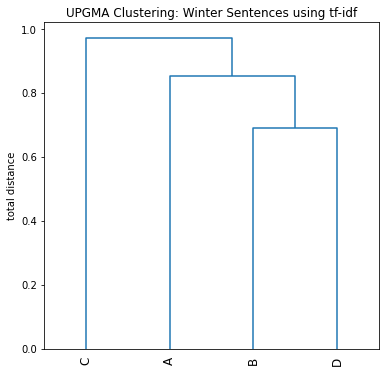

In [41]:
plot_dendrogram(filename2document, "Winter Sentences using tf-idf")

# Part 5 - Experiments and Discussion

Draw a dendrogram and discuss the results of your clustering for each of the following four experiments
* Poems using tf only
* Poems using tf-idf
* Books using tf only
* Books using tf-idf

Computing the dendrograms for the poems should take just a few seconds. Creating each dendrogram for the books could take up to a minute.

<Figure size 432x288 with 0 Axes>

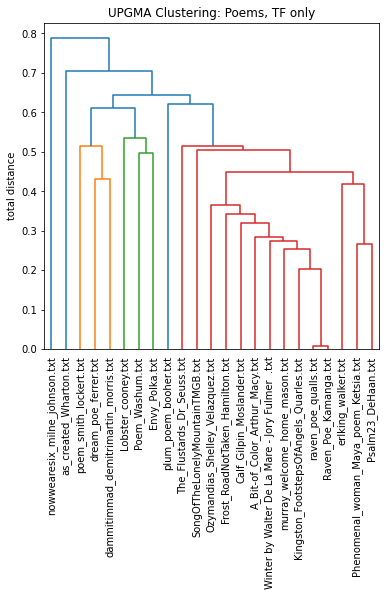

TF time: 0.76s


<Figure size 432x288 with 0 Axes>

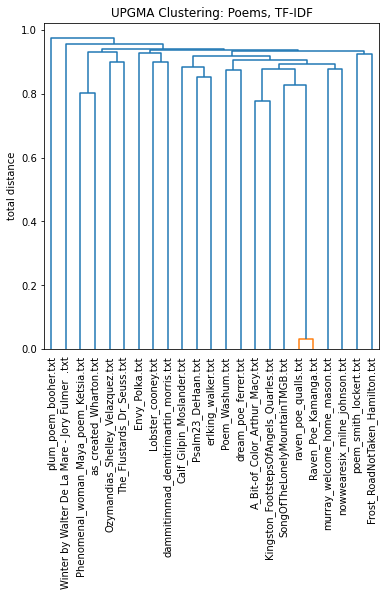

TF-IDF time: 0.65s
total time:  1.41s


In [42]:
import time
start = time.time()

poems = file_dictionary('/kaggle/input/poems-hendrix-csci-270-spring-2024')

plot_dendrogram(poems, "Poems, TF only", True)
tf_time = time.time() - start
print(f"TF time: {tf_time:.2f}s")

tf_idf_start = time.time()
plot_dendrogram(poems, "Poems, TF-IDF")
print(f"TF-IDF time: {time.time() - tf_idf_start:.2f}s")
print(f"total time:  {time.time() - start:.2f}s")

## Poem Discussion

1. Carefully read two poems that are relatively close to your poem in the TF-only clustering, and two poems that are distant from your poem. What specific aspects of these poems do you think are represented well by the TF-only concept? What are some aspects that TF-only overlooks?

The two closest poems to "Road Not Taken" are Calf and a bit of color. These poems are definitely well represented in the TF-Only by doing a good job with writing styles, such as words and complexity. I feel like the TF-Only overlooks basic stuff, such as patterns, such as rhyme within the text. These two different ones are psalm23 and "Now we are Six". It makes sense for psalm23 to be different than my poem because it is religious, not rhyming, and doesn't match the length.

2. Carefully read two poems that are relatively close to your poem in the TF-IDF clustering, and two poems that are distant from your poem. What specific aspects of these poems do you think are represented well by the TF-IDF concept? What are some aspects that TF-IDF overlooks?

The two closts ones in TF-IDF are "Now we are Six" and "Poem Smith Lockert". These poems are also well represented in the dendrogram and share some similarities with "Road Not Taken", such as length of the poems and estimated level of reading and sentiment.


<Figure size 432x288 with 0 Axes>

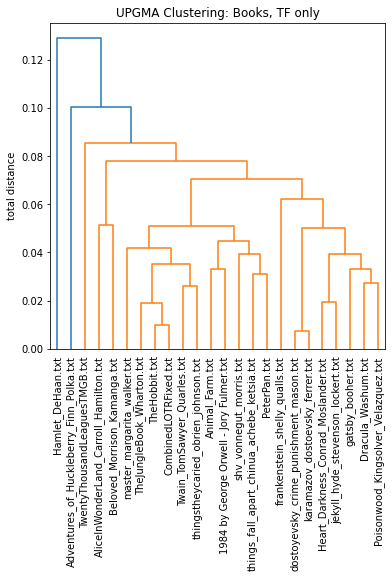

TF time: 27.80s


<Figure size 432x288 with 0 Axes>

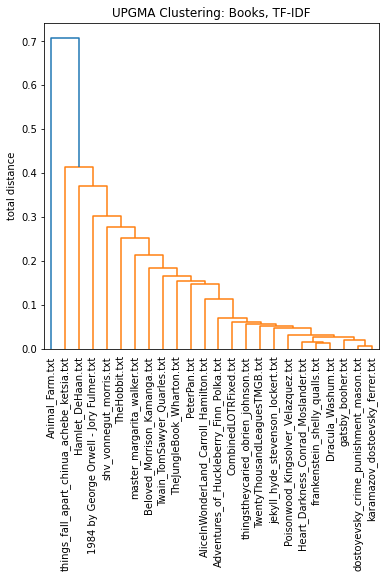

TF-IDF time: 28.08s
total time:  55.88s


In [43]:
start = time.time()
books = file_dictionary('/kaggle/input/novels-hendrix-csci-270-spring-2024')

plot_dendrogram(books, "Books, TF only", True)
tf_time = time.time() - start
print(f"TF time: {tf_time:.2f}s")

tf_idf_start = time.time()
plot_dendrogram(books, "Books, TF-IDF")
print(f"TF-IDF time: {time.time() - tf_idf_start:.2f}s")
print(f"total time:  {time.time() - start:.2f}s")

## Book Discussion

1. Skim a few pages of two books that are relatively close to your book in the TF-only clustering, and two books that are distant from your book.  What specific aspects of these books do you think are represented well by the TF-only concept? What are some aspects that TF-only overlooks?

In TF-Only, two books that are similar to mine are "20,000 Leagues Under" and "Beloved".20,000 is an adventure book so it should be kind of close to Alice, but it's not Reading a few pages from these books I would say that this clustering is not the most accurate. It is not taking into account the meaning of the book, it is just looking at how often words occur. This is not accurate because frequency of words don't mean anything without context

2. Skim a few pages of two books that are relatively close to your book in the TF-IDF clustering, and two books that are distant from your book.  What specific aspects of these books do you think are represented well by the TF-IDF concept? What are some aspects that TF-IDF overlooks?

In TF-Only, two books that are similar to mine are "Peter Pan" and the "Adventures of Huckleberry Fin". I love how it rated 2 children's adventure books as the most similar, so that means that the TF-IDF is more accurate than the regular TF. Peter Pan is almost identical story line to Alice in Wonderland. The rating represents the content of the book well and the meaning of the words.

## Summative Discussion

Compare and contrast the TF-only clustering with the TF-IDF clustering. Which corresponds better to your intuition about what makes documents similar? Why? Give specific examples from both the books and the poems to support your argument.

TF-IDF provides a more accurate representation of similarity between documents. I feel like it includes features that are left out of TF-Only. The IDF rates how important terms are rather than just how frequent they occur, so it will provide text that is likely very similar to other novels/poems that are similar. For example, Peter Pan was rated as very similar to Alice in Wonderland and they are pretty much the same story with different settings. A kind goes to a make belief place and goes on a wild adventure to fight the bad guy.


## Chapter Analysis

For your book, determine a scheme for dividing the book into sections. For most novels, dividing into chapters will work well. 

Break up your book into a dictionary where the keys are chapter names or numbers and the values are the contents of each chapter (or other pertinent subdivision).  Then apply `plot_dendrogram()`. Examine the dendrogram, and then answer the questions below.

The code below demonstrates how to do this for *The Brothers Karamazov*. Because it contains 192 "Chapters" and 42 "Books", I chose to break it up by "Book" instead of "Chapter". Carefully examine your own book to determine the right term to use to break it up.

This book has 16 chapters.


<Figure size 432x288 with 0 Axes>

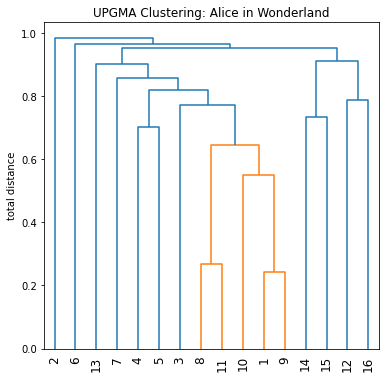

0.7491562366485596s


In [44]:
## Write code here to create the Chapter Analysis dendrogram.
start = time.time()
book_chapters = books['AliceInWonderLand_Carroll_Hamilton.txt'].split('Book')

book = {i: book_chapters[i] for i in range(1, len(book_chapters))}
print(f"This book has {len(book)} chapters.")
plot_dendrogram(book, "Alice in Wonderland")
print(f"{time.time() - start}s")

## Chapter Analysis Questions

1. Examine the various clusters of chapters. To what extent does the similarity among chapters correspond to different stages of the story and plot?

From what I saw, the adjacent chapters are more similar than chapters that are far apart from each other in the book. This makes since because the books follow a certain storyline, so they should have similar word

2. Does this clustering of chapters suggest to you any new insights about the book? Explain.

I think the chapters are a useful tool to analyze a piece of the book. It will only tell you about a fraction of the book, but it narrows the content down from the whole book and then is a bigger piece of data then sentences and paragraphs